# 判定价值曲线：第一、四象限

Miss 是极大的 offset，画在 200ms 那一端。纵轴从 1 到 -1，只使用第一、四象限。

锚点：(6, 1)，(44, 0)，(200, -1)。6ms 及以内为 1，200ms 及以外为 -1。

类余切贴着横轴。44ms 往 16ms，加成增加得很慢；16ms 往 6ms，加成增加得快。指数按 16ms ≈ 0.30 取，11ms 会落在 0.60 附近。

类反余切不是另一条独立公式。6–44 这一段，是类余切绕 (25, 0.5) 转 180°：(x, y) 读成 (50 − x, 1 − y)。44–200 同样，绕 (122, −0.5) 转 180°。所以它贴着 +1 和 −1，并在 (44, 0) 和类余切相交。


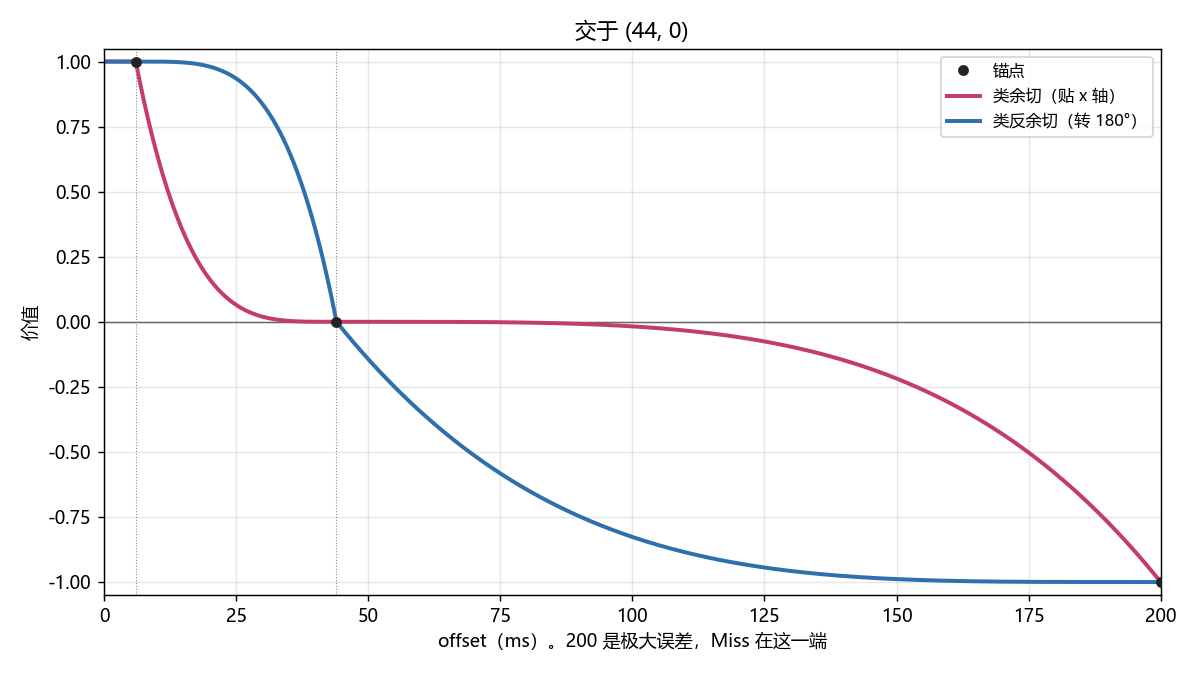

In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

FULL_MS = 6.0
ZERO_MS = 44.0
MISS_MS = 200.0
# (28/38)**p = 0.30，使类余切在 16ms 约为 0.30。
POWER = float(np.log(0.30) / np.log(28.0 / 38.0))


def cot_like(offset_ms, power=POWER):
    """贴横轴：44→16 慢，16→6 快。44→200 同样先贴着 0，快到 200 才落到 -1。"""
    e = np.asarray(offset_ms, dtype=float)
    left = np.clip((ZERO_MS - e) / (ZERO_MS - FULL_MS), 0.0, 1.0) ** power
    right = -np.clip((e - ZERO_MS) / (MISS_MS - ZERO_MS), 0.0, 1.0) ** power
    y = np.where(e <= ZERO_MS, left, right)
    y = np.where(e <= FULL_MS, 1.0, y)
    y = np.where(e >= MISS_MS, -1.0, y)
    return y


def arccot_like(offset_ms, power=POWER):
    """6–44 是类余切绕 (25, 0.5) 转 180°。44–200 绕 (122, -0.5) 转 180°。"""
    e = np.asarray(offset_ms, dtype=float)
    y = np.where(e <= ZERO_MS, 1.0 - cot_like(50.0 - e, power), -1.0 - cot_like(244.0 - e, power))
    y = np.where(e <= FULL_MS, 1.0, y)
    y = np.where(e >= MISS_MS, -1.0, y)
    y = np.where(np.isclose(e, ZERO_MS), 0.0, y)
    return y

offsets = np.linspace(0, 200, 4001)
fig, ax = plt.subplots(figsize=(9.2, 5.2))
ax.axhline(0, color="#666", lw=0.8)
ax.plot([6, 44, 200], [1, 0, -1], "o", color="#222", ms=5, zorder=5, label="锚点")
ax.plot(offsets, cot_like(offsets), color="#c43b6e", lw=2.2, label="类余切（贴 x 轴）")
ax.plot(offsets, arccot_like(offsets), color="#2f6fad", lw=2.2, label="类反余切（转 180°）")
for ms in (6, 44, 200):
    ax.axvline(ms, color="#888", lw=0.6, ls=":")
ax.set_xlim(0, 200)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("offset（ms）。200 是极大误差，Miss 在这一端")
ax.set_ylabel("价值")
ax.set_title("交于 (44, 0)")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.show()


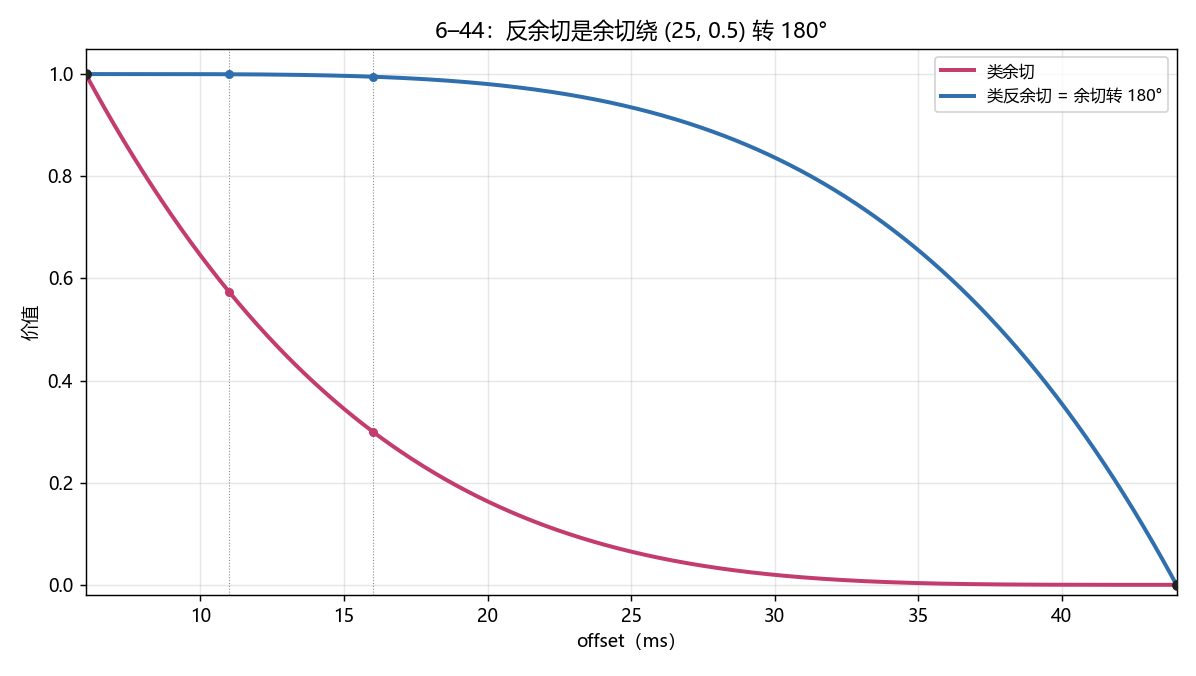

In [2]:
xs = np.linspace(6, 44, 800)
fig, ax = plt.subplots(figsize=(9.2, 5.2))
ax.plot(xs, cot_like(xs), color="#c43b6e", lw=2.2, label="类余切")
ax.plot(xs, arccot_like(xs), color="#2f6fad", lw=2.2, label="类反余切 = 余切转 180°")
ax.plot([6, 44], [1, 0], "o", color="#222", ms=5, zorder=5)
for ms in (11, 16):
    ax.axvline(ms, color="#888", lw=0.6, ls=":")
ax.set_xlim(6, 44)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("offset（ms）")
ax.set_ylabel("价值")
ax.set_title("6–44")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()


In [3]:
rows = [0, 6, 11, 16, 44, 80, 150, 200]
print(f"{'ms':<6}{'类余切':>10}{'类反余切':>10}")
for ms in rows:
    print(f"{ms:<6}{float(cot_like(ms)):>10.3f}{float(arccot_like(ms)):>10.3f}")
print(f"power {POWER:.3f}")


ms     类余切    类反余切
0         1.000      1.000
6         1.000      1.000
11        0.573      1.000
16        0.300      0.995
44        0.000      0.000
80       -0.003     -0.645
150      -0.218     -0.989
200      -1.000     -1.000
power  3.943


## 怎么读

类余切在 16ms 约为 0.30，11ms 约为 0.60。44ms 到 16ms 这一段抬得很慢，16ms 到 6ms 才快。

类反余切在同一段里是上面这条曲线转 180° 的结果，所以 16ms 和 11ms 都会很高，而且 11ms 仍然高于 16ms。过了 44ms 它很快落到 -1，类余切则继续贴着 0，直到靠近 200ms。

两条线只在 (44, 0) 交叉，两端分别重合于 (6, 1) 和 (200, -1)。
